In [116]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [117]:
class LinearRegression:

    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.weights = None
        self.bias = None

    def predict(self, feature):
        return np.dot(self.weights, feature) + self.bias

    def MSE(self, features, labels):
        total = 0
        for i, feature in enumerate(features):
            total += (self.predict(feature)-labels[i])**2
        return total/len(features)

    def MAE(self, features, labels):
        total = 0
        for i, feature in enumerate(features):
            total += np.abs(self.predict(feature)-labels[i])
        return total/len(features)

    def gradient(self, feature, label):
        dw = -2*feature * (label-self.predict(feature))
        db = -2*(label - self.predict(feature))
        return dw, db

    def fit(self, features, labels, epochs=200):
        features, labels = np.array(features), np.array(labels)
        self.weights = np.ones(len(features[0]))
        self.bias = 1
        errors = []
        for epoch in range(epochs):
            error = self.MSE(features, labels)
            errors.append(error)
            i = np.random.randint(len(features))
            dw, db = self.gradient(features[i], labels[i])
            self.weights = self.weights - (dw*self.learning_rate)
            self.bias = self.bias - (db*self.learning_rate)
        return self.weights, self.bias, errors





Weights:  [1.99779672]
Bias:  1.007958135509577


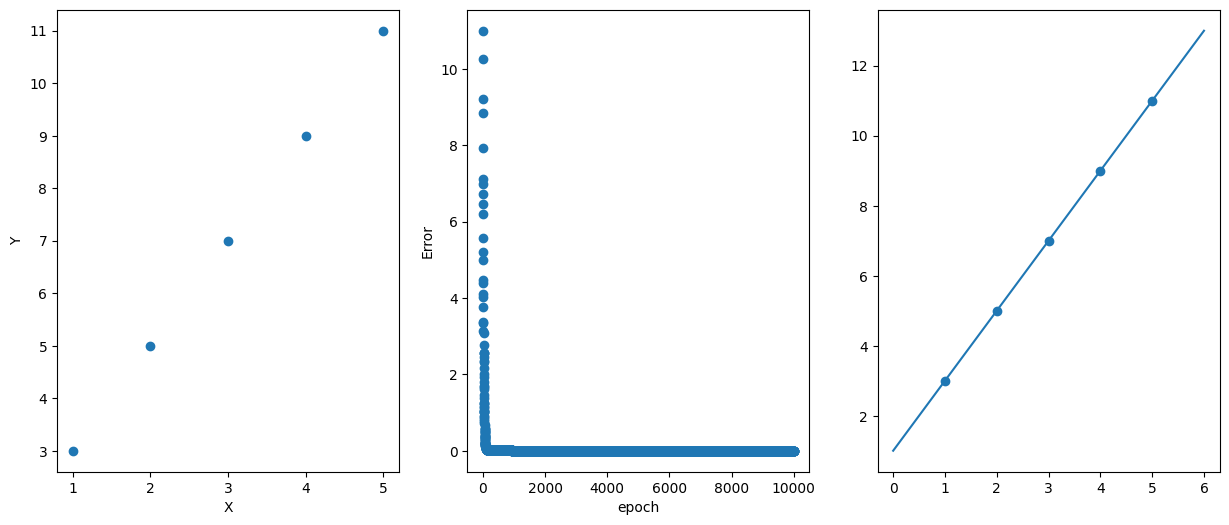

In [118]:
X = [[1], [2], [3], [4], [5]]
y = [3, 5, 7, 9, 11] #y=2x+1

fig, axes = plt.subplots(1, 3, figsize=(15,6))
axes[0].scatter(X, y)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

lr = LinearRegression(learning_rate=0.001)
weights, bias, errors = lr.fit(X, y, 10000)
print('Weights: ', weights)
print('Bias: ', bias)

axes[1].scatter(range(len(errors)), errors)
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('Error')

x_values = [0,6]
y_values = (x_values*weights+bias)
axes[2].scatter(X, y)
axes[2].plot(x_values, y_values)




plt.show()


In [ ]:
X = [
    [1, 1],
    [2, 1],
    [1, 2],
    [3, 2],
    [2, 3]
]

y = [6, 8, 9, 13, 14] # y = 2*x1+3*x2+1

fig, axes = plt.subplots(figsize=(8,6))

lr = LinearRegression(learning_rate=0.001)
weights, bias, errors = lr.fit(X, y, 100000)
print('Weights: ', weights)
print('Bias: ', bias)

axes.scatter(range(len(errors)), errors)
axes.set_xlabel('epoch')
axes.set_ylabel('Error')




plt.show()


Weights:  [2. 3.]
Bias:  1.0000000130809839
